# ITB video length analysis

This script is meant to be used after I have finished recording per-peptide time taken during the ITB meeting, before and after the predictions in the model. 

In [5]:
import os
from pathlib import Path
import pandas as pd


In [6]:
# Set the working directory
project_dir = Path("/Users/Jennie/Desktop/WashU/Rotation_labs/Griffith Lab/Neoantigen ML project")
os.chdir(project_dir)

# Define output directory
outdir = project_dir / "output_python" / "itb_video_analysis.ipynb"
os.makedirs(outdir, exist_ok=True)
print(f"Output directory created at: {outdir}")


Output directory created at: /Users/Jennie/Desktop/WashU/Rotation_labs/Griffith Lab/Neoantigen ML project/output_python/itb_video_analysis.ipynb


In [7]:
# Define IDs
pre_prediction_id = ["5120-39", "CTEP-10146-MD017-0052", "TWJF-5120-41", "TWJF-5120-42"]
post_prediction_id = ["10146-0053", "10146-0054", "10146-0062"]

# Video analysis data path
data_dir = project_dir / "ITB recordings" / "annotated files"


In [8]:
def read_and_clean_tsv(file_path):
    df = pd.read_csv(file_path, sep='\t')
    # Drop columns with '*' in their names
    cols_to_drop = [col for col in df.columns if '*' in col]
    df = df.drop(columns=cols_to_drop)
    return df

# Build file paths for pre- and post-prediction IDs
pre_files = [data_dir / f"{id}_merged_python_R_predictions.tsv" for id in pre_prediction_id]
post_files = [data_dir / f"{id}_merged_python_R_predictions.tsv" for id in post_prediction_id]

# Read and clean each file, then merge
pre_dfs = [read_and_clean_tsv(f) for f in pre_files]
post_dfs = [read_and_clean_tsv(f) for f in post_files]

# Concatenate (merge) all dataframes for pre and post
pre_merged = pd.concat(pre_dfs, ignore_index=True)
post_merged = pd.concat(post_dfs, ignore_index=True)

# Now pre_merged and post_merged contain your merged data


New columns seems to have been added to later versions of pvacseq (analysis below show new columns include 'Num Included Peptides', 'Index')

In [9]:
# Get the set of columns for each DataFrame
pre_cols = set(pre_merged.columns)
post_cols = set(post_merged.columns)

# Columns only in pre_merged
only_in_pre = pre_cols - post_cols

# Columns only in post_merged
only_in_post = post_cols - pre_cols

print("Columns only in pre_merged:")
print(only_in_pre)

print("\nColumns only in post_merged:")
print(only_in_post)

print("\nColumns in both:")
print(pre_cols & post_cols)


Columns only in pre_merged:
set()

Columns only in post_merged:
{'Num Included Peptides', 'Index'}

Columns in both:
{'R_Evaluation_pred', 'Best Transcript', 'IC50 WT', 'python_Accept_pred_prob', 'IC50 MT', 'ID', 'R_Accept_pred_prob', 'TSL', 'Pos', 'Allele', 'AA Change', 'Comments', 'RNA Depth', 'Best Peptide', '%ile WT', 'RNA VAF', 'Num Passing Peptides', 'RNA Expr', 'Mutation', 'Num Passing Transcripts', 'Tier', 'Allele Expr', 'Evaluation', 'Prob Pos', 'Gene', 'ITB_review_time_seconds', 'Ref Match', '%ile MT', 'python_Evaluation_pred', 'DNA VAF'}


Check if ITB_review_time_seconds are normallly distributed (if yes -> T test. If not -> non-parametric tests)

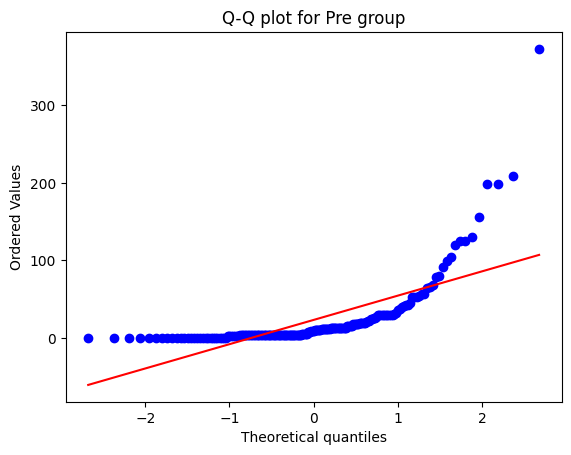

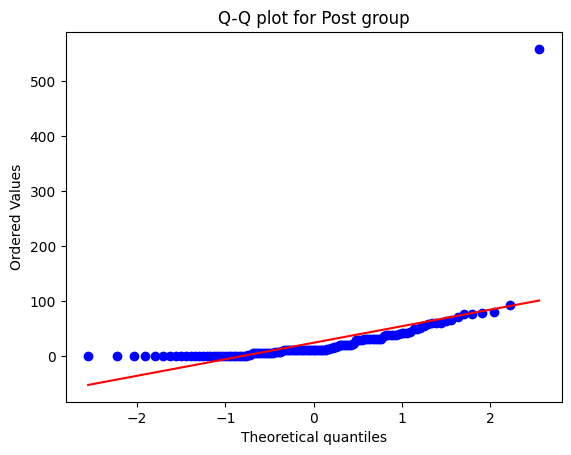

In [11]:
import scipy.stats as stats
import matplotlib.pyplot as plt

pre_times = pre_merged['ITB_review_time_seconds'].dropna()
post_times = post_merged['ITB_review_time_seconds'].dropna()

stats.probplot(pre_times, dist="norm", plot=plt)
plt.title("Q-Q plot for Pre group")
plt.show()

stats.probplot(post_times, dist="norm", plot=plt)
plt.title("Q-Q plot for Post group")
plt.show()


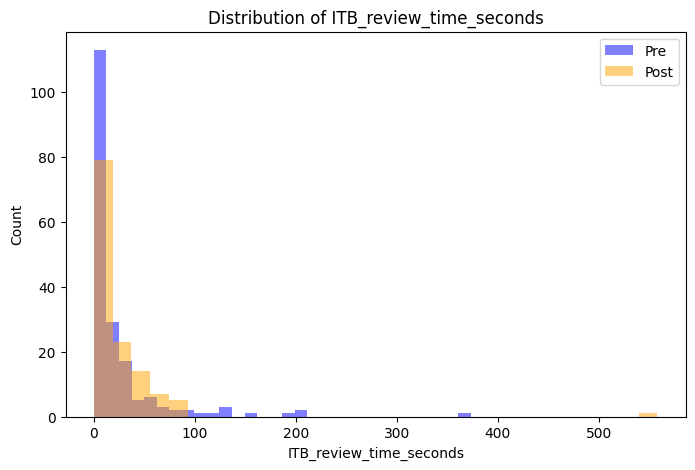

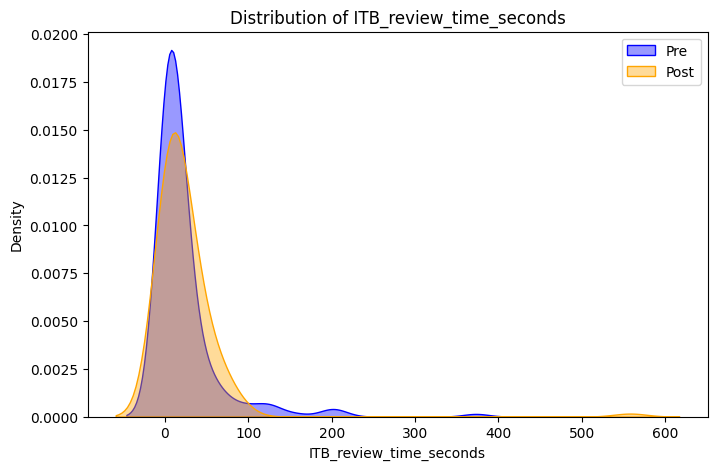

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(pre_merged['ITB_review_time_seconds'].dropna(), bins=30, alpha=0.5, label='Pre', color='blue')
plt.hist(post_merged['ITB_review_time_seconds'].dropna(), bins=30, alpha=0.5, label='Post', color='orange')
plt.xlabel('ITB_review_time_seconds')
plt.ylabel('Count')
plt.title('Distribution of ITB_review_time_seconds')
plt.legend()
plt.show()

import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(pre_merged['ITB_review_time_seconds'].dropna(), label='Pre', fill=True, color='blue', alpha=0.4)
sns.kdeplot(post_merged['ITB_review_time_seconds'].dropna(), label='Post', fill=True, color='orange', alpha=0.4)
plt.xlabel('ITB_review_time_seconds')
plt.ylabel('Density')
plt.title('Distribution of ITB_review_time_seconds')
plt.legend()
plt.show()


Box plot to visualize the difference in review time

In [22]:
from scipy.stats import ttest_ind, mannwhitneyu, ks_2samp

# t-test
#t_stat, t_p = ttest_ind(pre_times, post_times, equal_var=False)
#print(f"t-test: p={t_p}")

# Mann-Whitney U test
u_stat, u_p = mannwhitneyu(pre_times, post_times, alternative='less')
print(f"Mann-Whitney U: p={u_p}")

# Kolmogorov-Smirnov test
ks_stat, ks_p = ks_2samp(pre_times, post_times)
print(f"KS test: p={ks_p}")


Mann-Whitney U: p=0.06199998085289253
KS test: p=0.0029450703892066063


Since frame shift mutations are still mostly being manuallly reviewed, we perform the statistical tests again without them being included in the data. 

In [23]:
# Filter to only keep rows with Mutation == "missense"
pre_missense = pre_merged[pre_merged["Mutation"] == "missense"]
post_missense = post_merged[post_merged["Mutation"] == "missense"]

# Extract the ITB_review_time_seconds column, dropping any missing values
pre_times_missense = pre_missense['ITB_review_time_seconds'].dropna()
post_times_missense = post_missense['ITB_review_time_seconds'].dropna()

# Perform Mann-Whitney U test
u_stat, u_p = mannwhitneyu(pre_times_missense, post_times_missense, alternative='less')
print(f"Mann-Whitney U (missense only): p={u_p}")


Mann-Whitney U (missense only): p=0.10253381442255266
